### Set up

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import gc

### A (TD)

In [13]:
# 1. 設定路徑與抓取受試者名單
base_dir = '/home/p2894/mne_eeg_workshop/ds006777/derivatives'
subject_paths = glob.glob(os.path.join(base_dir, 'sub-*'))
#subject_ids = sorted([os.path.basename(p) for p in subject_paths if os.path.isdir(p)])
subject_ids = ['sub-10025', 'sub-10036', 'sub-10177']#, 'sub-11038', 'sub-11049', 'sub-11053']

In [14]:
print(f"預計處理的受試者: {subject_ids}\n")

預計處理的受試者: ['sub-10025', 'sub-10036', 'sub-10177']



In [15]:
# 2. 準備一個「空列表」來收集所有人的 TFR (Time-Frequency Representation) 結果
all_power_A = []

In [16]:
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']
freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0  # different number of cycle per frequency

--- 正在計算 sub-10025 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10025/sub-10025_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
303 matching events found
No baseline correction applied
0 projection items activated
--- 正在計算 sub-10036 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10036/sub-10036_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
375 matching events found
No baseline correction applied
0 projection items activated
--- 正在計算 sub-10177 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10177/sub-10177_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
124 matching events found
No baseline c

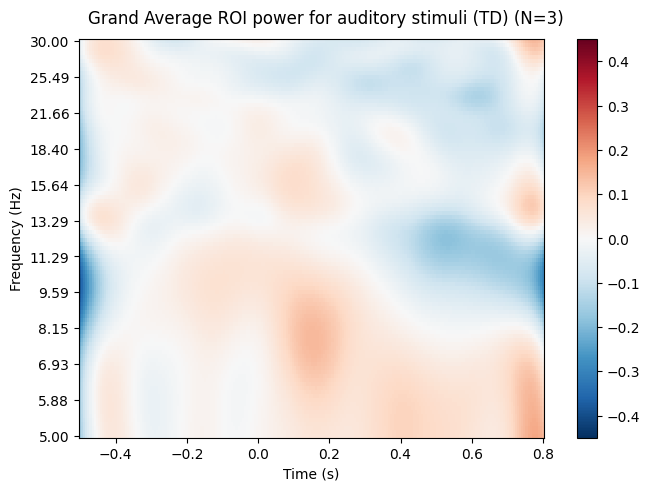

In [17]:
# 3. 開始批次處理迴圈
for subject_id in subject_ids:
    print(f"--- 正在計算 {subject_id} 的 TFR ---")
    
    epochs_path = os.path.join(base_dir, subject_id, f'{subject_id}_eeg-epo.fif')
    
    try:
        # 讀取該受試者的 Epochs
        epochs = mne.read_epochs(epochs_path, preload=True)
        epochs_A = epochs['A']  # 只取 Condition A
        
        # 計算 TFR (注意: average=True 會回傳 AverageTFR 物件，這正是 grand_average 需要的)
        power_A = epochs_A.compute_tfr(
            method="morlet", 
            freqs=freqs, 
            n_cycles=n_cycles, 
            average=True, 
            decim=3, 
            picks=roi_channels
        )
        
        # ★ 關鍵步驟：把算好的結果加進列表裡
        all_power_A.append(power_A)
        
    except Exception as e:
        print(f"❌ {subject_id} 處理失敗: {e}")
        
    finally:
        # 釋放記憶體，避免跑太多人 RAM 爆炸
        if 'epochs' in locals(): del epochs
        if 'epochs_A' in locals(): del epochs_A
        gc.collect()

print("\n==== 所有受試者計算完畢 ====")

# 4. 計算 Grand Average 並畫圖
if len(all_power_A) > 0:
    print(f"\n正在計算 {len(all_power_A)} 位受試者的 Grand Average...")
    
    # 使用 mne.grand_average 將列表中所有人的 TFR 平均起來
    grand_power_A = mne.grand_average(all_power_A)
    
    # 畫出最終的平均圖
    grand_power_A.plot(
        picks=roi_channels, 
        baseline=(-0.5, 0), 
        mode="logratio", 
        combine='mean', 
        title=f'Grand Average ROI power for auditory stimuli (TD) (N={len(all_power_A)})',
        vlim=(-0.45, 0.45)
    )
else:
    print("沒有成功載入任何受試者的資料。")

### A (ASC)

In [18]:
subject_ids = ['sub-11038', 'sub-11049', 'sub-11053']
print(f"預計處理的受試者: {subject_ids}\n")

預計處理的受試者: ['sub-11038', 'sub-11049', 'sub-11053']



In [19]:
all_power_A = []
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']
freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0

--- 正在計算 sub-11038 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11038/sub-11038_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
48 matching events found
No baseline correction applied
0 projection items activated
--- 正在計算 sub-11049 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11049/sub-11049_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
281 matching events found
No baseline correction applied
0 projection items activated
--- 正在計算 sub-11053 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11053/sub-11053_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
132 matching events found
No baseline co

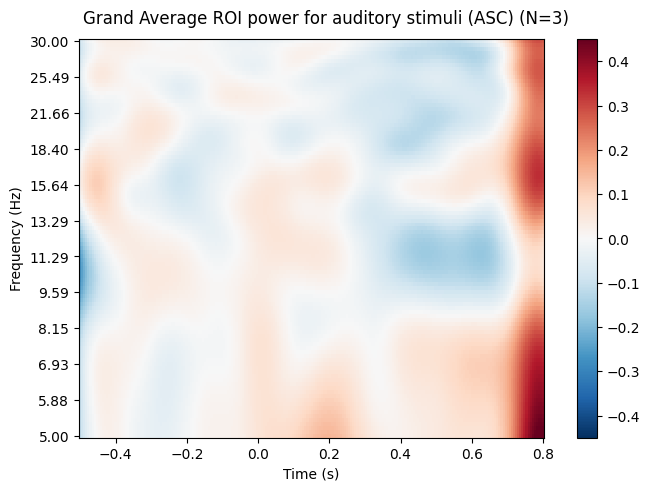

In [20]:
# 3. 開始批次處理迴圈
for subject_id in subject_ids:
    print(f"--- 正在計算 {subject_id} 的 TFR ---")
    
    epochs_path = os.path.join(base_dir, subject_id, f'{subject_id}_eeg-epo.fif')
    
    try:
        # 讀取該受試者的 Epochs
        epochs = mne.read_epochs(epochs_path, preload=True)
        epochs_A = epochs['A']  # 只取 Condition A
        
        # 計算 TFR (注意: average=True 會回傳 AverageTFR 物件，這正是 grand_average 需要的)
        power_A = epochs_A.compute_tfr(
            method="morlet", 
            freqs=freqs, 
            n_cycles=n_cycles, 
            average=True, 
            decim=3, 
            picks=roi_channels
        )
        
        # ★ 關鍵步驟：把算好的結果加進列表裡
        all_power_A.append(power_A)
        
    except Exception as e:
        print(f"❌ {subject_id} 處理失敗: {e}")
        
    finally:
        # 釋放記憶體，避免跑太多人 RAM 爆炸
        if 'epochs' in locals(): del epochs
        if 'epochs_A' in locals(): del epochs_A
        gc.collect()

print("\n==== 所有受試者計算完畢 ====")

# 4. 計算 Grand Average 並畫圖
if len(all_power_A) > 0:
    print(f"\n正在計算 {len(all_power_A)} 位受試者的 Grand Average...")
    
    # 使用 mne.grand_average 將列表中所有人的 TFR 平均起來
    grand_power_A = mne.grand_average(all_power_A)
    
    # 畫出最終的平均圖
    grand_power_A.plot(
        picks=roi_channels, 
        baseline=(-0.5, 0), 
        mode="logratio", 
        combine='mean', 
        title=f'Grand Average ROI power for auditory stimuli (ASC) (N={len(all_power_A)})',
        vlim=(-0.45, 0.45)
    )
else:
    print("沒有成功載入任何受試者的資料。")

In [21]:
epochs = mne.read_epochs('/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-1501/sub-1501_eeg-epo.fif')

Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-1501/sub-1501_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
371 matching events found
No baseline correction applied
0 projection items activated


### V (TD)

In [23]:
subject_ids = ['sub-10025', 'sub-10036', 'sub-10177']
all_power_V = []
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']
freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0

--- 正在計算 sub-10025 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10025/sub-10025_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
303 matching events found
No baseline correction applied
0 projection items activated
--- 正在計算 sub-10036 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10036/sub-10036_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
375 matching events found
No baseline correction applied
0 projection items activated
--- 正在計算 sub-10177 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10177/sub-10177_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
124 matching events found
No baseline c

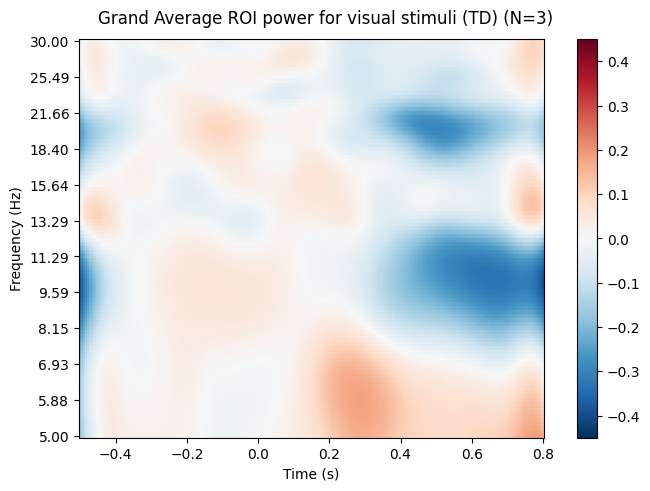

In [24]:
# 3. 開始批次處理迴圈
for subject_id in subject_ids:
    print(f"--- 正在計算 {subject_id} 的 TFR ---")
    
    epochs_path = os.path.join(base_dir, subject_id, f'{subject_id}_eeg-epo.fif')
    
    try:
        # 讀取該受試者的 Epochs
        epochs = mne.read_epochs(epochs_path, preload=True)
        epochs_V = epochs['V']  # 只取 Condition A
        
        # 計算 TFR (注意: average=True 會回傳 AverageTFR 物件，這正是 grand_average 需要的)
        power_V = epochs_V.compute_tfr(
            method="morlet", 
            freqs=freqs, 
            n_cycles=n_cycles, 
            average=True, 
            decim=3, 
            picks=roi_channels
        )
        
        # ★ 關鍵步驟：把算好的結果加進列表裡
        all_power_V.append(power_V)
        
    except Exception as e:
        print(f"❌ {subject_id} 處理失敗: {e}")
        
    finally:
        # 釋放記憶體，避免跑太多人 RAM 爆炸
        if 'epochs' in locals(): del epochs
        if 'epochs_V' in locals(): del epochs_V
        gc.collect()

print("\n==== 所有受試者計算完畢 ====")

# 4. 計算 Grand Average 並畫圖
if len(all_power_V) > 0:
    print(f"\n正在計算 {len(all_power_V)} 位受試者的 Grand Average...")
    
    # 使用 mne.grand_average 將列表中所有人的 TFR 平均起來
    grand_power_V = mne.grand_average(all_power_V)
    
    # 畫出最終的平均圖
    grand_power_V.plot(
        picks=roi_channels, 
        baseline=(-0.5, 0), 
        mode="logratio", 
        combine='mean', 
        title=f'Grand Average ROI power for visual stimuli (TD) (N={len(all_power_V)})',
        vlim=(-0.45, 0.45)
    )
else:
    print("沒有成功載入任何受試者的資料。")

### V (ASC)

In [25]:
subject_ids = ['sub-11038', 'sub-11049', 'sub-11053']
all_power_V = []
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']
freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0

--- 正在計算 sub-11038 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11038/sub-11038_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
48 matching events found
No baseline correction applied
0 projection items activated
--- 正在計算 sub-11049 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11049/sub-11049_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
281 matching events found
No baseline correction applied
0 projection items activated
--- 正在計算 sub-11053 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11053/sub-11053_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
132 matching events found
No baseline co

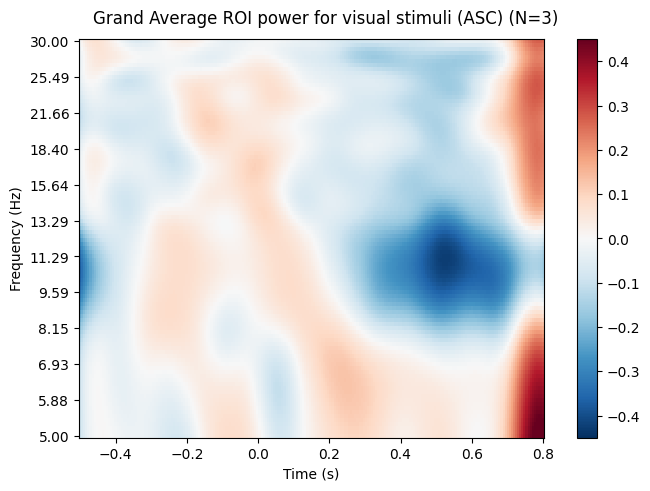

In [26]:
# 3. 開始批次處理迴圈
for subject_id in subject_ids:
    print(f"--- 正在計算 {subject_id} 的 TFR ---")
    
    epochs_path = os.path.join(base_dir, subject_id, f'{subject_id}_eeg-epo.fif')
    
    try:
        # 讀取該受試者的 Epochs
        epochs = mne.read_epochs(epochs_path, preload=True)
        epochs_V = epochs['V']  # 只取 Condition A
        
        # 計算 TFR (注意: average=True 會回傳 AverageTFR 物件，這正是 grand_average 需要的)
        power_V = epochs_V.compute_tfr(
            method="morlet", 
            freqs=freqs, 
            n_cycles=n_cycles, 
            average=True, 
            decim=3, 
            picks=roi_channels
        )
        
        # ★ 關鍵步驟：把算好的結果加進列表裡
        all_power_V.append(power_V)
        
    except Exception as e:
        print(f"❌ {subject_id} 處理失敗: {e}")
        
    finally:
        # 釋放記憶體，避免跑太多人 RAM 爆炸
        if 'epochs' in locals(): del epochs
        if 'epochs_V' in locals(): del epochs_V
        gc.collect()

print("\n==== 所有受試者計算完畢 ====")

# 4. 計算 Grand Average 並畫圖
if len(all_power_V) > 0:
    print(f"\n正在計算 {len(all_power_V)} 位受試者的 Grand Average...")
    
    # 使用 mne.grand_average 將列表中所有人的 TFR 平均起來
    grand_power_V = mne.grand_average(all_power_V)
    
    # 畫出最終的平均圖
    grand_power_V.plot(
        picks=roi_channels, 
        baseline=(-0.5, 0), 
        mode="logratio", 
        combine='mean', 
        title=f'Grand Average ROI power for visual stimuli (ASC) (N={len(all_power_V)})',
        vlim=(-0.45, 0.45)
    )
else:
    print("沒有成功載入任何受試者的資料。")

### AV (TD)

In [27]:
subject_ids = ['sub-10025', 'sub-10036', 'sub-10177']
all_power_AV = []
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']
freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0

--- 正在計算 sub-10025 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10025/sub-10025_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
303 matching events found
No baseline correction applied
0 projection items activated
--- 正在計算 sub-10036 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10036/sub-10036_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
375 matching events found
No baseline correction applied
0 projection items activated
--- 正在計算 sub-10177 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10177/sub-10177_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
124 matching events found
No baseline c

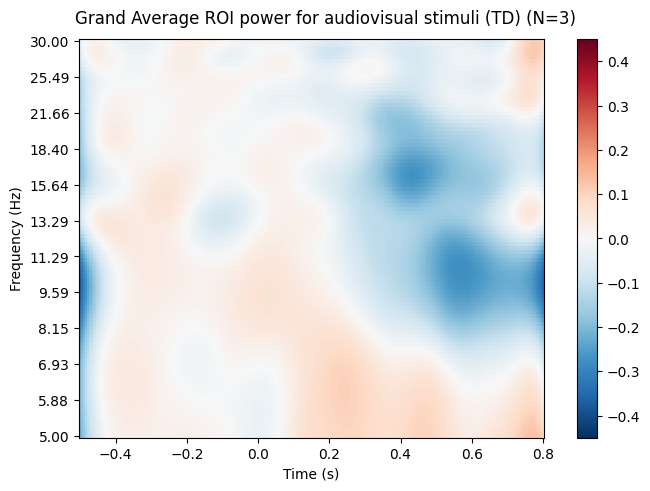

In [28]:
# 3. 開始批次處理迴圈
for subject_id in subject_ids:
    print(f"--- 正在計算 {subject_id} 的 TFR ---")
    
    epochs_path = os.path.join(base_dir, subject_id, f'{subject_id}_eeg-epo.fif')
    
    try:
        # 讀取該受試者的 Epochs
        epochs = mne.read_epochs(epochs_path, preload=True)
        epochs_AV = epochs['AV']  # 只取 Condition A
        
        # 計算 TFR (注意: average=True 會回傳 AverageTFR 物件，這正是 grand_average 需要的)
        power_AV = epochs_AV.compute_tfr(
            method="morlet", 
            freqs=freqs, 
            n_cycles=n_cycles, 
            average=True, 
            decim=3, 
            picks=roi_channels
        )
        
        # ★ 關鍵步驟：把算好的結果加進列表裡
        all_power_AV.append(power_AV)
        
    except Exception as e:
        print(f"❌ {subject_id} 處理失敗: {e}")
        
    finally:
        # 釋放記憶體，避免跑太多人 RAM 爆炸
        if 'epochs' in locals(): del epochs
        if 'epochs_AV' in locals(): del epochs_AV
        gc.collect()

print("\n==== 所有受試者計算完畢 ====")

# 4. 計算 Grand Average 並畫圖
if len(all_power_AV) > 0:
    print(f"\n正在計算 {len(all_power_AV)} 位受試者的 Grand Average...")
    
    # 使用 mne.grand_average 將列表中所有人的 TFR 平均起來
    grand_power_AV = mne.grand_average(all_power_AV)
    
    # 畫出最終的平均圖
    grand_power_AV.plot(
        picks=roi_channels, 
        baseline=(-0.5, 0), 
        mode="logratio", 
        combine='mean', 
        title=f'Grand Average ROI power for audiovisual stimuli (TD) (N={len(all_power_AV)})',
        vlim=(-0.45, 0.45)
    )
else:
    print("沒有成功載入任何受試者的資料。")

### AV (ASC)

In [29]:
subject_ids = ['sub-11038', 'sub-11049', 'sub-11053']
all_power_AV = []
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']
freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0

--- 正在計算 sub-11038 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11038/sub-11038_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
48 matching events found
No baseline correction applied
0 projection items activated
--- 正在計算 sub-11049 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11049/sub-11049_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
281 matching events found
No baseline correction applied
0 projection items activated
--- 正在計算 sub-11053 的 TFR ---
Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11053/sub-11053_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
132 matching events found
No baseline co

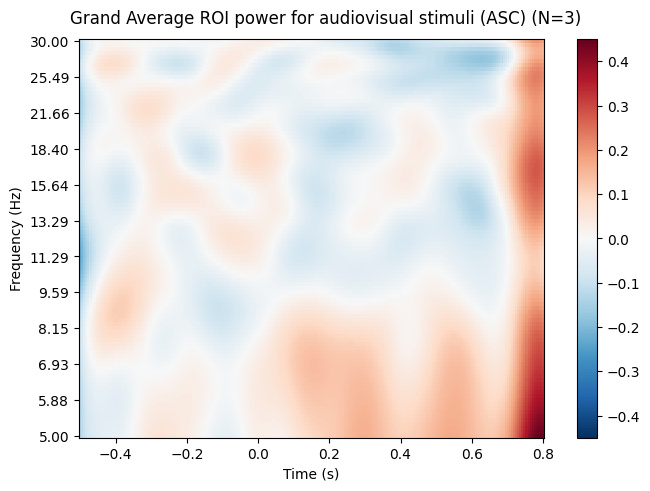

In [30]:
# 3. 開始批次處理迴圈
for subject_id in subject_ids:
    print(f"--- 正在計算 {subject_id} 的 TFR ---")
    
    epochs_path = os.path.join(base_dir, subject_id, f'{subject_id}_eeg-epo.fif')
    
    try:
        # 讀取該受試者的 Epochs
        epochs = mne.read_epochs(epochs_path, preload=True)
        epochs_AV = epochs['AV']  # 只取 Condition A
        
        # 計算 TFR (注意: average=True 會回傳 AverageTFR 物件，這正是 grand_average 需要的)
        power_AV = epochs_AV.compute_tfr(
            method="morlet", 
            freqs=freqs, 
            n_cycles=n_cycles, 
            average=True, 
            decim=3, 
            picks=roi_channels
        )
        
        # ★ 關鍵步驟：把算好的結果加進列表裡
        all_power_AV.append(power_AV)
        
    except Exception as e:
        print(f"❌ {subject_id} 處理失敗: {e}")
        
    finally:
        # 釋放記憶體，避免跑太多人 RAM 爆炸
        if 'epochs' in locals(): del epochs
        if 'epochs_AV' in locals(): del epochs_AV
        gc.collect()

print("\n==== 所有受試者計算完畢 ====")

# 4. 計算 Grand Average 並畫圖
if len(all_power_AV) > 0:
    print(f"\n正在計算 {len(all_power_AV)} 位受試者的 Grand Average...")
    
    # 使用 mne.grand_average 將列表中所有人的 TFR 平均起來
    grand_power_AV = mne.grand_average(all_power_AV)
    
    # 畫出最終的平均圖
    grand_power_AV.plot(
        picks=roi_channels, 
        baseline=(-0.5, 0), 
        mode="logratio", 
        combine='mean', 
        title=f'Grand Average ROI power for audiovisual stimuli (ASC) (N={len(all_power_AV)})',
        vlim=(-0.45, 0.45)
    )
else:
    print("沒有成功載入任何受試者的資料。")

### A

In [4]:
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']

freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0  # different number of cycle per frequency
power_A = epochs_A.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    decim=3,
    picks=roi_channels
)

In [13]:
power.shape

(5, 100, 223)

Applying baseline correction (mode: logratio)


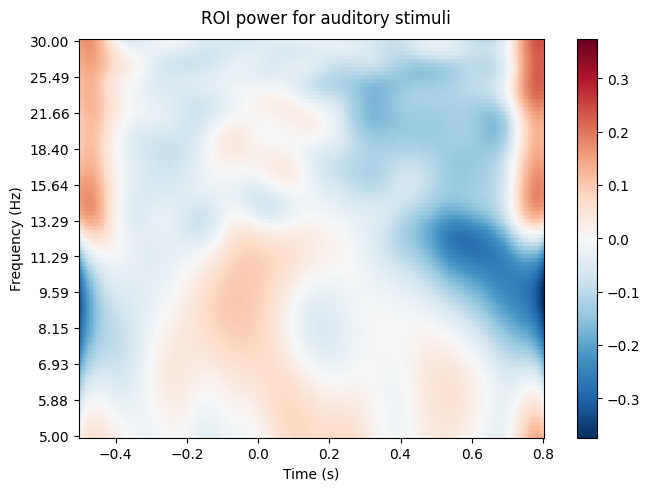

[<Figure size 640x480 with 2 Axes>]

In [5]:
#power.plot_topo(baseline=(-0.5, 0), mode="logratio", title="Average power") 
power_A.plot(picks=roi_channels, baseline=(-0.5, 0), mode="logratio", combine='mean', title='ROI power for auditory stimuli')

In [26]:
epochs_A

<EpochsFIF | 120 events (all good), -0.5 – 0.801 s (baseline -0.2 – 0 s), ~44.7 MiB, data loaded,
 'A': 120>

### V

In [6]:
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']

freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0  # different number of cycle per frequency
power_V = epochs_V.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    decim=3,
    picks=roi_channels
)

Applying baseline correction (mode: logratio)


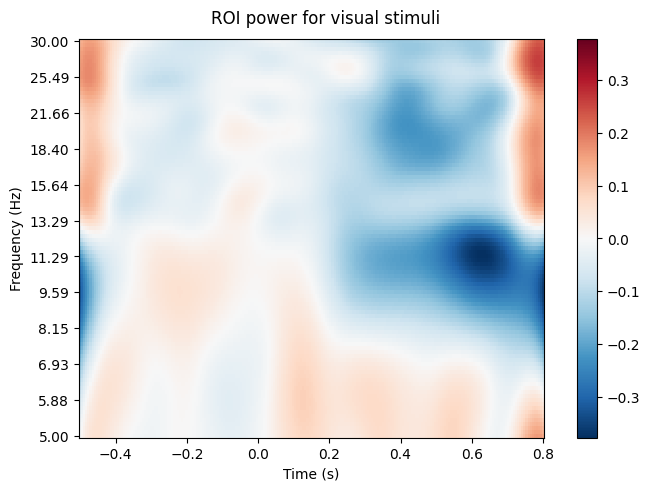

[<Figure size 640x480 with 2 Axes>]

In [7]:
power_V.plot(picks=roi_channels, baseline=(-0.5, 0), mode="logratio", combine='mean', title='ROI power for visual stimuli')

### AV

In [8]:
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']

freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0  # different number of cycle per frequency
power_AV = epochs_AV.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    decim=3,
    picks=roi_channels
)

Applying baseline correction (mode: logratio)


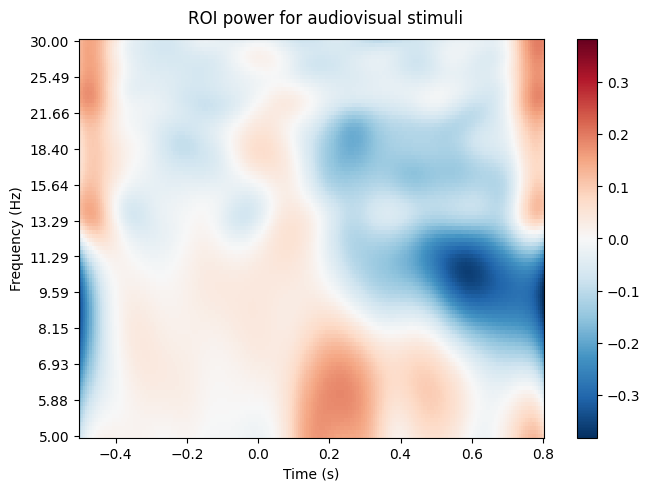

[<Figure size 640x480 with 2 Axes>]

In [9]:
power_AV.plot(picks=roi_channels, baseline=(-0.5, 0), mode="logratio", combine='mean', title='ROI power for audiovisual stimuli')

### MSI effect

In [10]:
power_AV_minus_A = power_AV - power_A

Applying baseline correction (mode: logratio)


/home/p2894/mne_eeg_workshop/.venv/lib/python3.12/site-packages/mne/baseline.py:115: RuntimeWarning: invalid value encountered in log10
  np.log10(d, out=d)


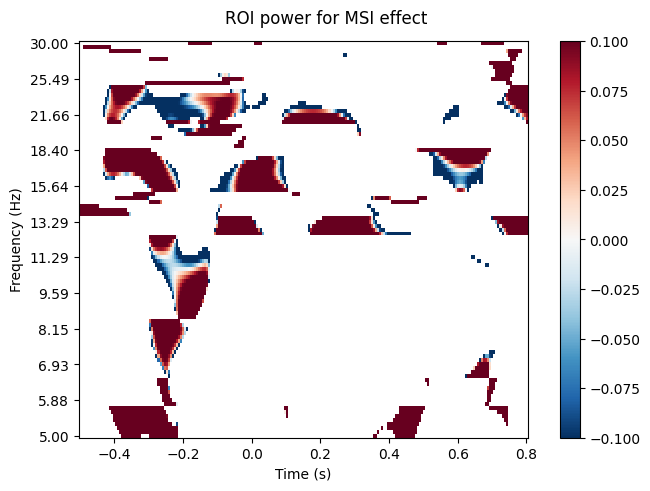

[<Figure size 640x480 with 2 Axes>]

In [11]:
power_AV_minus_A.plot(picks=roi_channels, baseline=(-0.5, 0), mode="logratio", combine='mean', title='ROI power for MSI effect')

Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)


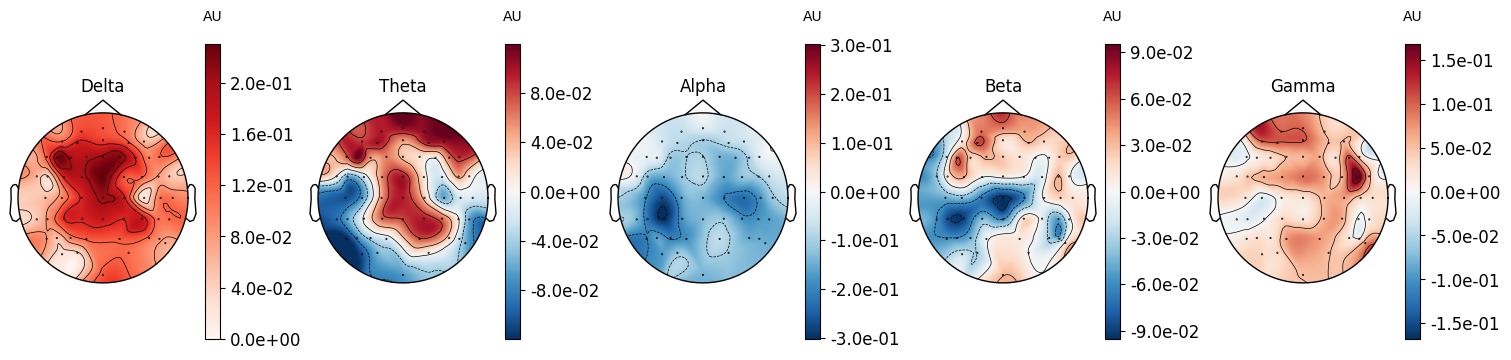

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5), layout="constrained")
topomap_kw = dict(
    ch_type="eeg", tmin=0.5, tmax=1.5, baseline=(-0.5, 0), mode="logratio", show=False
)
plot_dict = dict(Delta=dict(fmin=1, fmax=4), Theta=dict(fmin=4, fmax=8), Alpha=dict(fmin=8, fmax=12), Beta=dict(fmin=13, fmax=30), Gamma=dict(fmin=30, fmax=40))
for ax, (title, fmin_fmax) in zip(axes, plot_dict.items()):
    power.plot_topomap(**fmin_fmax, axes=ax, **topomap_kw)
    ax.set_title(title)

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


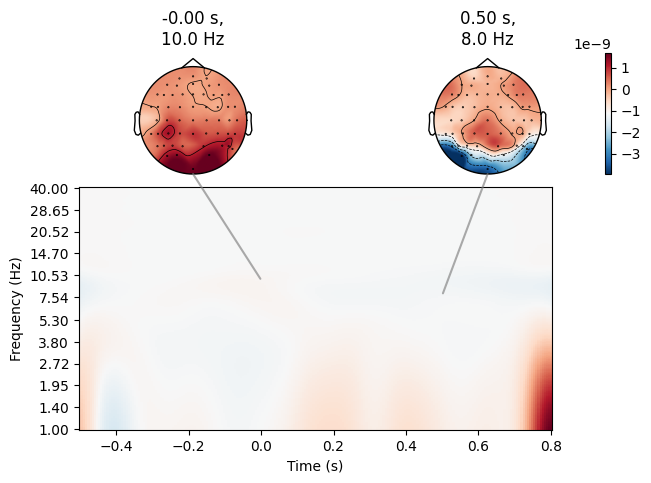

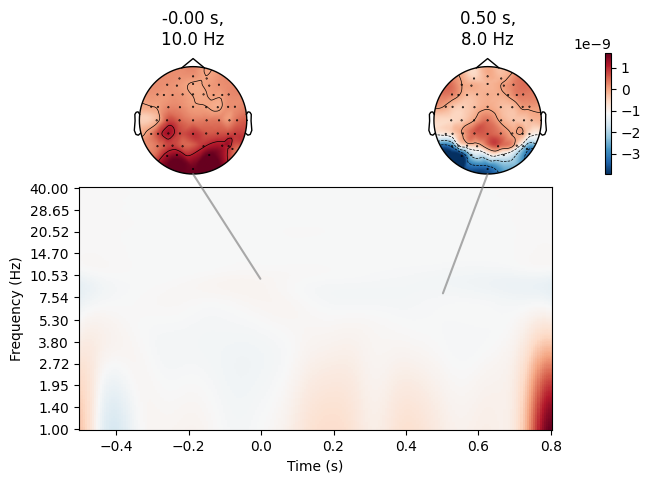

In [19]:
power.plot_joint(
    baseline=(-0.5, 0), mode="mean", tmin=-0.5, tmax=2, timefreqs=[(0, 10), (0.5, 8)]
)

In [ ]:
# Time-frequency analysis for each quartile 
freqs = np.linspace(*np.array([2, 40]), num=200) #num = step / bin allows a precision of the frequency resolution
n_cycles = freqs / 2  # different number of cycle per frequency
    
# Total power for each quartile
power_A = mne.time_frequency.tfr_morlet(epochs_A, freqs=freqs, n_cycles=n_cycles, use_fft=True,
                            output = 'complex', return_itc=False, decim=1, n_jobs=1, average=False)
# Compute Time-Frequency Representation (TFR) using Morlet wavelets, which operates on Epochs or Evoked objects instead of NumPy arrays.
# https://mne.tools/stable/generated/mne.time_frequency.tfr_morlet.html